In [7]:
import pandas as pd
import numpy as np
import random
import tensorflow as tf

# set seed
seed = 42
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

# read data
df = pd.read_csv("Nino3.4_data.csv")
# set train data and test data 
test_years = pd.read_csv("test_years.csv")['year'].values
test_df = df[df['year'].isin(test_years)]
trainval_df = df[~df['year'].isin(test_years)]

# split train and val
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(trainval_df, test_size=0.2, random_state=seed)
feature_cols = ['nino_tminus2', 'nino_tminus1', 'nino_t', 'month']

# encode the cyclical nature of months
train_df['month_sin'] = np.sin(2 * np.pi * train_df['month'] / 12)
train_df['month_cos'] = np.cos(2 * np.pi * train_df['month'] / 12)
val_df['month_sin'] = np.sin(2 * np.pi * val_df['month'] / 12)
val_df['month_cos'] = np.cos(2 * np.pi * val_df['month'] / 12)
test_df['month_sin'] = np.sin(2 * np.pi * test_df['month'] / 12)
test_df['month_cos'] = np.cos(2 * np.pi * test_df['month'] / 12)

feature_cols = ['nino_tminus2', 'nino_tminus1', 'nino_t', 'month_sin', 'month_cos']

C:\Users\19658\AppData\Local\Temp\ipykernel_3804\321213744.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['month_sin'] = np.sin(2 * np.pi * test_df['month'] / 12)
C:\Users\19658\AppData\Local\Temp\ipykernel_3804\321213744.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['month_cos'] = np.cos(2 * np.pi * test_df['month'] / 12)


In [8]:
from sklearn.preprocessing import StandardScaler
import joblib

# scale the input data
scaler_x = StandardScaler()
X_train = scaler_x.fit_transform(train_df[feature_cols])
X_val = scaler_x.transform(val_df[feature_cols])
X_test = scaler_x.transform(test_df[feature_cols])

# save scale
joblib.dump(scaler_x, 'scaler_X.pkl')

target_scalers = {}
Y_train_scaled, Y_val_scaled, Y_test_scaled = {}, {}, {}

# nino_tplus1 ~ nino_tplus6 output scaler
for i in range(1, 7):  
    target = f"nino_tplus{i}"
    scaler_y = StandardScaler()
    Y_train_scaled[target] = scaler_y.fit_transform(train_df[[target]])
    Y_val_scaled[target] = scaler_y.transform(val_df[[target]])
    Y_test_scaled[target] = scaler_y.transform(test_df[[target]])
    target_scalers[target] = scaler_y
    joblib.dump(scaler_y, f'scaler_{target}.pkl')

In [9]:
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.callbacks import EarlyStopping

# set the model
def build_model(input_dim):
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(input_dim,), kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        layers.Dropout(0.2),
        layers.Dense(1)
    ])
    model.compile(optimizer=optimizers.Adam(1e-3), loss='mse')
    return model

history_dict = {}

# build the model for each data
for i in range(1, 7):
    target = f'nino_tplus{i}'
    model = build_model(len(feature_cols))

    # early stop
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    
    history = model.fit(
        X_train, Y_train_scaled[target],
        validation_data=(X_val, Y_val_scaled[target]),
        epochs=80,
        batch_size=32,
        verbose=0,
        callbacks=[early_stop]
    )

    # save the model for graph
    model.save(f'model_{target}.keras')
    history_dict[target] = history.history
    print(f'{target} done')


E:\UNSW_software\python\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


nino_tplus1 done
nino_tplus2 done
nino_tplus3 done
nino_tplus4 done
nino_tplus5 done
nino_tplus6 done


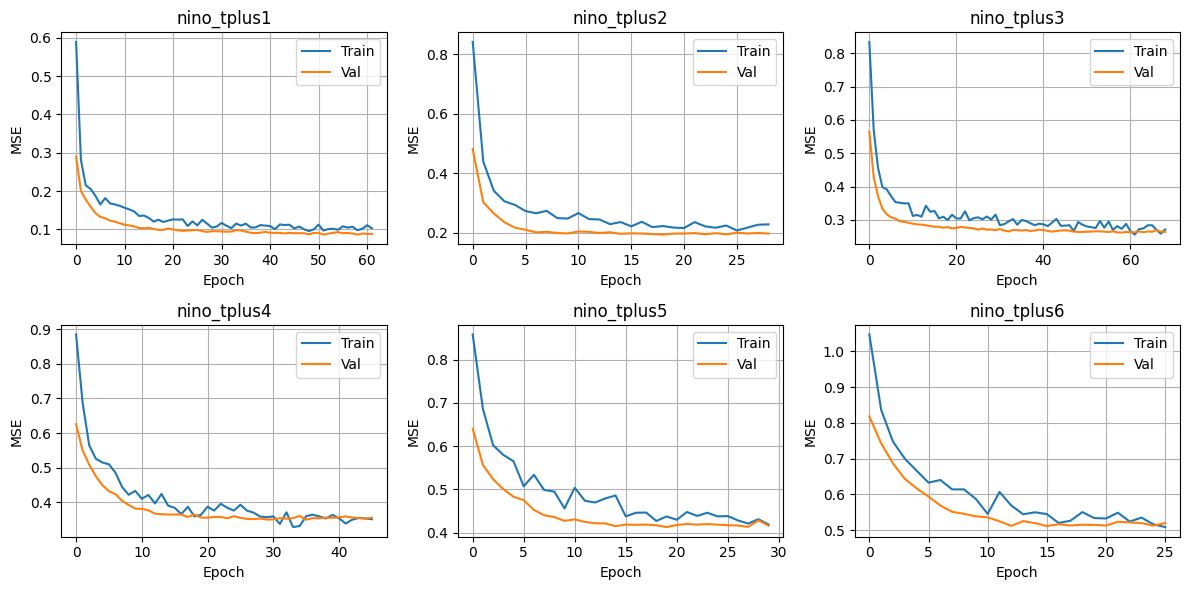

In [10]:
import matplotlib.pyplot as plt

# set the structure
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

# show graph
for i in range(1, 7):
    target = f'nino_tplus{i}'
    hist = history_dict[target]
    ax = axes[i-1]
    ax.plot(hist['loss'], label='Train')
    ax.plot(hist['val_loss'], label='Val')
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE")
    ax.set_title(target)
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


In [11]:
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

results = []

for i in range(1, 7):
    target = f'nino_tplus{i}'
    model = tf.keras.models.load_model(f'model_{target}.keras')
    y_pred_scaled = model.predict(X_test)
    y_pred = target_scalers[target].inverse_transform(y_pred_scaled)
    y_true = test_df[[target]].values
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    corr, pea = pearsonr(y_true.flatten(), y_pred.flatten())
    results.append((target, rmse, corr))
results_df = pd.DataFrame(results, columns=['Target', 'RMSE', 'Corr'])
print(results_df)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/stepWARNING:tensorflow:6 out of the last 32 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x00000213341F3A60> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
       

In [12]:
# import model1
base_model = tf.keras.models.load_model('model_nino_tplus1.keras')

# froze layers (except last one)
for layer in base_model.layers[:-1]:
    layer.trainable = False

# exchange the output layer
transfer_model = models.Sequential(base_model.layers[:-1] + [
    layers.Dense(1, name='transfer_output')
])

transfer_model.compile(
    optimizer=optimizers.Adam(2e-4),
    loss='mse'
)

# train for model6
target = 'nino_tplus6'
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

history_transfer = transfer_model.fit(
    X_train, Y_train_scaled[target],
    validation_data=(X_val, Y_val_scaled[target]),
    epochs=150,
    batch_size=32,
    verbose=0,
    callbacks=[early_stop]
)
print('base training done')

# fine-tune 1
for layer in transfer_model.layers[:-1]:
    layer.trainable = True

transfer_model.compile(
    optimizer=optimizers.Adam(5e-5),
    loss='mse'
)

history_stage2 = transfer_model.fit(
    X_train, Y_train_scaled[target],
    validation_data=(X_val, Y_val_scaled[target]),
    epochs=150,
    batch_size=32,
    verbose=0,
    callbacks=[early_stop]
)
print('fine-tune 1 done')

# fine-tune 2
for layer in transfer_model.layers:
    layer.trainable = True

transfer_model.compile(
    optimizer=optimizers.Adam(1e-5),
    loss='mse'
)

history_stage3 = transfer_model.fit(
    X_train, Y_train_scaled[target],
    validation_data=(X_val, Y_val_scaled[target]),
    epochs=100,
    batch_size=32,
    verbose=0,
    callbacks=[early_stop]
)
print('fine-tune 2 done')

transfer_model.save('model_transfer_finetuned_nino_tplus6.keras')

base training done
fine-tune 1 done
fine-tune 2 done


In [13]:
# import model
target = 'nino_tplus6'
transfer_model = tf.keras.models.load_model('model_transfer_finetuned_nino_tplus6.keras')
base_model_t6 = tf.keras.models.load_model('model_nino_tplus6.keras')

# import scale data
scaler_x = joblib.load('scaler_X.pkl')
scaler_y = joblib.load(f'scaler_{target}.pkl')

X_test_scaled = scaler_x.transform(test_df[feature_cols])
y_true = test_df[[target]].values

# tl_data
y_pred_transfer_scaled = transfer_model.predict(X_test_scaled)
y_pred_transfer = scaler_y.inverse_transform(y_pred_transfer_scaled)

# base data
y_pred_base_scaled = base_model_t6.predict(X_test_scaled)
y_pred_base = scaler_y.inverse_transform(y_pred_base_scaled)

# RMSE
rmse_transfer = np.sqrt(mean_squared_error(y_true, y_pred_transfer))
rmse_base = np.sqrt(mean_squared_error(y_true, y_pred_base))

# Pearson
corr_transfer, _ = pearsonr(y_true.flatten(), y_pred_transfer.flatten())
corr_base, _ = pearsonr(y_true.flatten(), y_pred_base.flatten())

print(f"base： RMSE = {rmse_base:.4f},  Pearson_r = {corr_base:.4f}")
print(f"transfer： RMSE = {rmse_transfer:.4f},  Pearson_r = {corr_transfer:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
base： RMSE = 0.7268,  Pearson_r = 0.6665
transfer： RMSE = 0.7369,  Pearson_r = 0.6636


In [ ]:
# TASK 2

In [14]:
# import the data
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

df_multi = pd.read_csv("Nino3.4_data.csv")
test_years_multi = pd.read_csv("test_years.csv")['year'].values

test_df_multi = df_multi[df_multi['year'].isin(test_years_multi)]
trainval_df_multi = df_multi[~df_multi['year'].isin(test_years_multi)]

# split train/val
train_df_multi, val_df_multi = train_test_split(trainval_df_multi, test_size=0.2, random_state=seed, shuffle=True)

In [15]:
for dset in [train_df_multi, val_df_multi, test_df_multi]:
    dset['month_sin'] = np.sin(2 * np.pi * dset['month'] / 12)
    dset['month_cos'] = np.cos(2 * np.pi * dset['month'] / 12)
    
# init the scaler
feature_cols_multi = ['nino_tminus2', 'nino_tminus1', 'nino_t', 'month_sin', 'month_cos']
target_cols_multi = [f'nino_tplus{i}' for i in range(1, 7)]

X_train_multi = train_df_multi[feature_cols_multi].values
X_val_multi = val_df_multi[feature_cols_multi].values
X_test_multi = test_df_multi[feature_cols_multi].values

Y_train_multi = train_df_multi[target_cols_multi].values
Y_val_multi = val_df_multi[target_cols_multi].values
Y_test_multi = test_df_multi[target_cols_multi].values

# scaler input and output
scaler_X_multi = StandardScaler().fit(X_train_multi)
X_train_multi = scaler_X_multi.transform(X_train_multi)
X_val_multi = scaler_X_multi.transform(X_val_multi)
X_test_multi = scaler_X_multi.transform(X_test_multi)

scaler_Y_multi = StandardScaler().fit(Y_train_multi)
Y_train_multi = scaler_Y_multi.transform(Y_train_multi)
Y_val_multi = scaler_Y_multi.transform(Y_val_multi)
Y_test_multi = scaler_Y_multi.transform(Y_test_multi)

# save scaler
joblib.dump(scaler_X_multi, "scaler_X_multi.pkl")
joblib.dump(scaler_Y_multi, "scaler_Y_multi.pkl")

C:\Users\19658\AppData\Local\Temp\ipykernel_3804\611895073.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dset['month_sin'] = np.sin(2 * np.pi * dset['month'] / 12)
C:\Users\19658\AppData\Local\Temp\ipykernel_3804\611895073.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dset['month_cos'] = np.cos(2 * np.pi * dset['month'] / 12)


['scaler_Y_multi.pkl']

In [16]:
# build the model
def build_multi_model(input_dim):
    model = models.Sequential([
        layers.Dense(128, activation='relu', input_shape=(input_dim,), kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        layers.Dropout(0.2),
        layers.Dense(6)  # output layer for 6 months 
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse')
    return model

model_multi = build_multi_model(len(feature_cols_multi))

early_stop_multi = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

history_multi = model_multi.fit(
    X_train_multi, Y_train_multi,
    validation_data=(X_val_multi, Y_val_multi),
    epochs=200,
    batch_size=32,
    verbose=0,
    callbacks=[early_stop_multi]
)

model_multi.save("model_multi_output.keras")

E:\UNSW_software\python\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 39: early stopping
Restoring model weights from the end of the best epoch: 29.


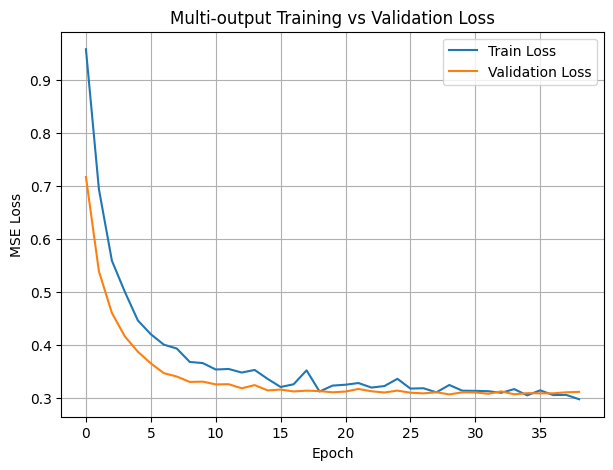

In [17]:
# graph
plt.figure(figsize=(7, 5))
plt.plot(history_multi.history['loss'], label='Train Loss')
plt.plot(history_multi.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Multi-output Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
# result for 6 predicts
Y_pred_scaled_multi = model_multi.predict(X_test_multi)
Y_pred_multi = scaler_Y_multi.inverse_transform(Y_pred_scaled_multi)
Y_true_multi = test_df_multi[target_cols_multi].values

metrics_multi = []
for i, target in enumerate(target_cols_multi):
    rmse = np.sqrt(mean_squared_error(Y_true_multi[:, i], Y_pred_multi[:, i]))
    corr, _ = pearsonr(Y_true_multi[:, i], Y_pred_multi[:, i])
    metrics_multi.append((target, rmse, corr))

metrics_df_multi = pd.DataFrame(metrics_multi, columns=["Target", "RMSE", "Corr"])
print(metrics_df_multi)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
        Target      RMSE      Corr
0  nino_tplus1  0.214877  0.976134
1  nino_tplus2  0.368640  0.926886
2  nino_tplus3  0.472538  0.872085
3  nino_tplus4  0.565105  0.806332
4  nino_tplus5  0.630991  0.752493
5  nino_tplus6  0.695171  0.707255


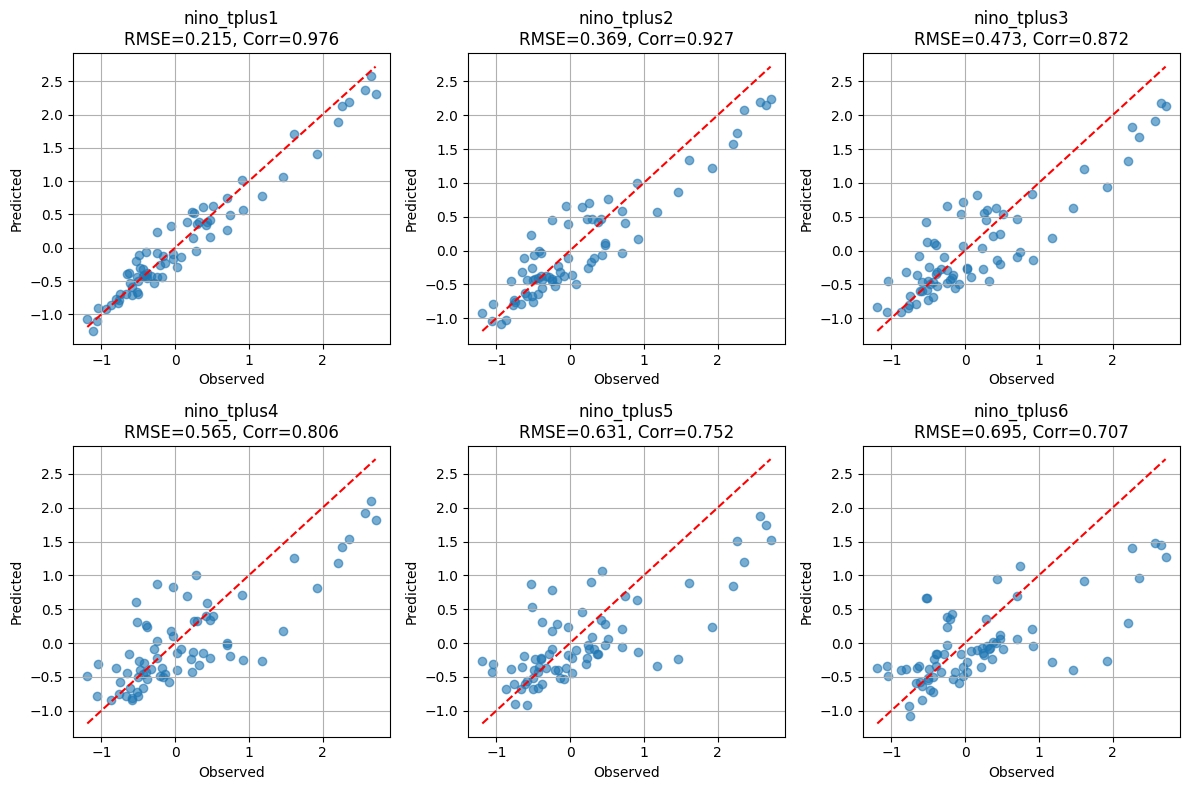

In [19]:
# graph
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, target in enumerate(target_cols_multi):
    ax = axes[i]
    ax.scatter(Y_true_multi[:, i], Y_pred_multi[:, i], alpha=0.6)
    ax.plot(
        [Y_true_multi[:, i].min(), Y_true_multi[:, i].max()],
        [Y_true_multi[:, i].min(), Y_true_multi[:, i].max()],
        'r--'
    )
    rmse = np.sqrt(mean_squared_error(Y_true_multi[:, i], Y_pred_multi[:, i]))
    corr, _ = pearsonr(Y_true_multi[:, i], Y_pred_multi[:, i])
    ax.set_title(f"{target}\nRMSE={rmse:.3f}, Corr={corr:.3f}")
    ax.set_xlabel("Observed")
    ax.set_ylabel("Predicted")
    ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# TASK 2.1 weight

In [20]:
# define weight
def weighted_mse(weights):
    weights = tf.constant(weights, dtype=tf.float32)
    def loss(y_true, y_pred):
        mse = tf.square(y_true - y_pred)
        weighted = mse * weights
        return tf.reduce_mean(weighted)
    return loss

# weights (based on rmse form base-model)
rmse_values = metrics_df_multi["RMSE"].values
weights = 1 / rmse_values
weights = weights / np.mean(weights)
#weights = rmse_values / np.mean(rmse_values)
print("weights:", np.round(weights, 3))

weights: [1.956 1.14  0.889 0.744 0.666 0.605]


In [21]:
# build model (weight)
n_features = X_train_multi.shape[1]
n_outputs = Y_train_multi.shape[1]

model_weighted = models.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(n_outputs)  # 6 years
])

model_weighted.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3), 
    loss=weighted_mse(weights)
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# training
history_w = model_weighted.fit(
    X_train_multi, Y_train_multi,
    validation_data=(X_val_multi, Y_val_multi),
    epochs=100,
    batch_size=32,
    verbose=0,
    callbacks=[early_stop]
)

# save model
model_weighted.save("multioutput_weighted_model.keras")

Epoch 59: early stopping
Restoring model weights from the end of the best epoch: 49.


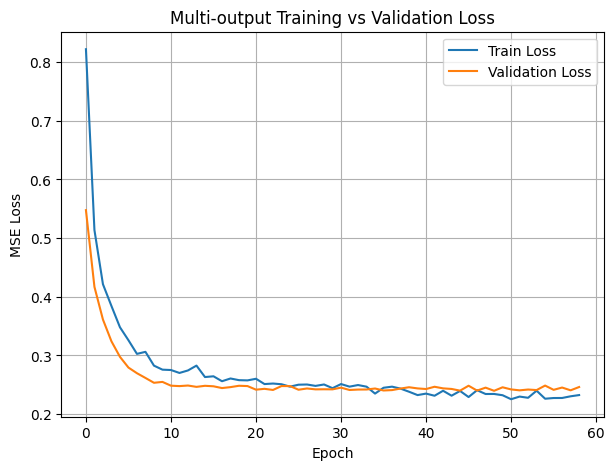

In [22]:
# graph
plt.figure(figsize=(7, 5))
plt.plot(history_w.history['loss'], label='Train Loss')
plt.plot(history_w.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Multi-output Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
# result
Y_pred_scaled_weighted = model_weighted.predict(X_test_multi)
Y_pred_weighted = scaler_Y_multi.inverse_transform(Y_pred_scaled_weighted)
Y_true_multi = test_df_multi[target_cols_multi].values

metrics_weighted = []
for i, target in enumerate(target_cols_multi):
    rmse = np.sqrt(mean_squared_error(Y_true_multi[:, i], Y_pred_weighted[:, i]))
    corr, _ = pearsonr(Y_true_multi[:, i], Y_pred_weighted[:, i])
    metrics_weighted.append((target, rmse, corr))

metrics_df_weighted = pd.DataFrame(metrics_weighted, columns=["Target", "RMSE", "Corr"])
print('weight:')
print(metrics_df_weighted)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
weight:
        Target      RMSE      Corr
0  nino_tplus1  0.212625  0.977558
1  nino_tplus2  0.373450  0.924214
2  nino_tplus3  0.475931  0.870053
3  nino_tplus4  0.562326  0.809415
4  nino_tplus5  0.639316  0.744904
5  nino_tplus6  0.691016  0.697142


In [24]:
target_cols = results_df['Target'].tolist()

comparison_df = pd.DataFrame({
    "Target": target_cols,
    "RMSE_TaskA": results_df["RMSE"].values,
    "RMSE_TaskB_std": metrics_df_multi["RMSE"].values,
    "RMSE_TaskB_weight": metrics_df_weighted["RMSE"].values,
    "Corr_TaskA": results_df["Corr"].values,
    "Corr_TaskB_std": metrics_df_multi["Corr"].values,
    "Corr_TaskB_weight": metrics_df_weighted["Corr"].values
})

avg_rmse = comparison_df[["RMSE_TaskA","RMSE_TaskB_std","RMSE_TaskB_weight"]].mean()
avg_corr = comparison_df[["Corr_TaskA","Corr_TaskB_std","Corr_TaskB_weight"]].mean()
comparison_df.loc["Average"] = ["Average"] + list(avg_rmse) + list(avg_corr)

comparison_df["RMSE_Improvement_TaskA_%"] = 100 * (comparison_df["RMSE_TaskB_std"] - comparison_df["RMSE_TaskA"]) / comparison_df["RMSE_TaskB_std"]
comparison_df["RMSE_Improvement_TaskB_weight_%"] = 100 * (comparison_df["RMSE_TaskB_std"] - comparison_df["RMSE_TaskB_weight"]) / comparison_df["RMSE_TaskB_std"]

comparison_df["Corr_Improvement_TaskA_%"] = 100 * (comparison_df["Corr_TaskA"] - comparison_df["Corr_TaskB_std"]) / comparison_df["Corr_TaskB_std"]
comparison_df["Corr_Improvement_TaskB_weight_%"] = 100 * (comparison_df["Corr_TaskB_weight"] - comparison_df["Corr_TaskB_std"]) / comparison_df["Corr_TaskB_std"]

print(comparison_df[['Target','RMSE_TaskA','RMSE_TaskB_std','RMSE_TaskB_weight', "Corr_TaskA", "Corr_TaskB_std", "Corr_TaskB_weight"]])
print()
print(comparison_df[["RMSE_Improvement_TaskA_%", "RMSE_Improvement_TaskB_weight_%"]])
print()
print(comparison_df[["Corr_Improvement_TaskA_%", "Corr_Improvement_TaskB_weight_%"]])

              Target  RMSE_TaskA  RMSE_TaskB_std  RMSE_TaskB_weight  \
0        nino_tplus1    0.208850        0.214877           0.212625   
1        nino_tplus2    0.367351        0.368640           0.373450   
2        nino_tplus3    0.505094        0.472538           0.475931   
3        nino_tplus4    0.597121        0.565105           0.562326   
4        nino_tplus5    0.666098        0.630991           0.639316   
5        nino_tplus6    0.726801        0.695171           0.691016   
Average      Average    0.511886        0.491220           0.492444   

         Corr_TaskA  Corr_TaskB_std  Corr_TaskB_weight  
0          0.978889        0.976134           0.977558  
1          0.929416        0.926886           0.924214  
2          0.851756        0.872085           0.870053  
3          0.788582        0.806332           0.809415  
4          0.723984        0.752493           0.744904  
5          0.666487        0.707255           0.697142  
Average    0.823186        0.840

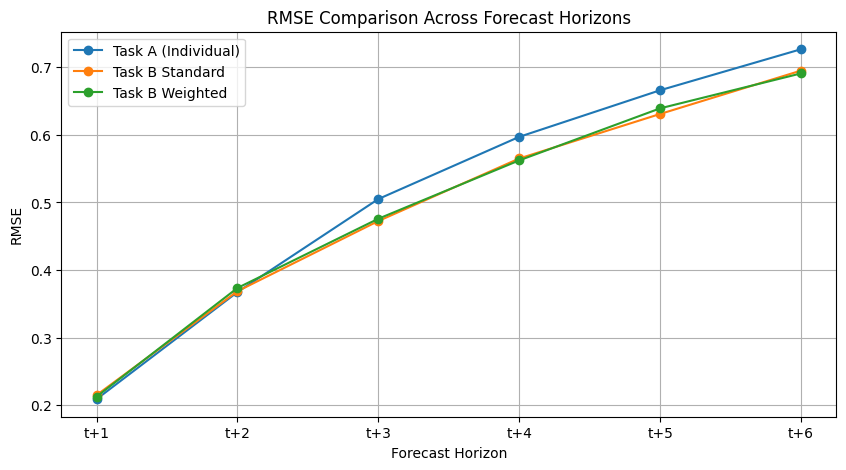

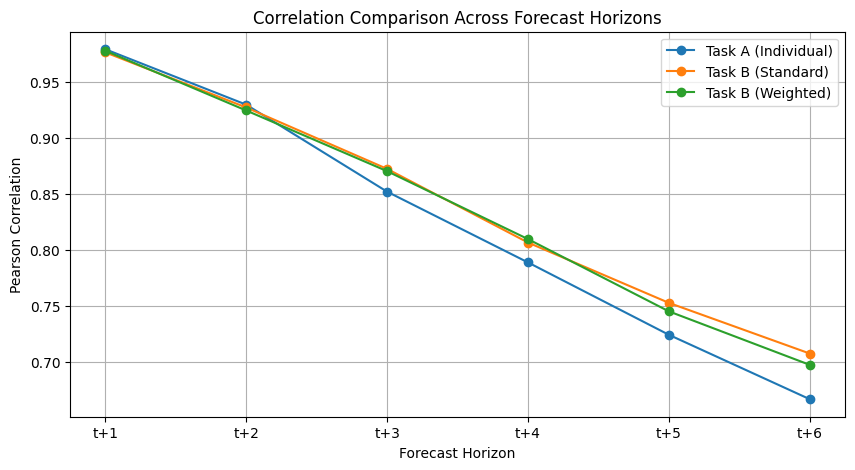

In [25]:
import matplotlib.pyplot as plt
import numpy as np

horizons = [f"t+{i}" for i in range(1, 7)]

# RMSE
plt.figure(figsize=(10, 5))
plt.plot(horizons, comparison_df.loc[:5, "RMSE_TaskA"], marker='o', label="Task A (Individual)")
plt.plot(horizons, comparison_df.loc[:5, "RMSE_TaskB_std"], marker='o', label="Task B Standard")
plt.plot(horizons, comparison_df.loc[:5, "RMSE_TaskB_weight"], marker='o', label="Task B Weighted")
plt.xlabel("Forecast Horizon")
plt.ylabel("RMSE")
plt.title("RMSE Comparison Across Forecast Horizons")
plt.legend()
plt.grid(True)
plt.show()

# Corr
plt.figure(figsize=(10, 5))
plt.plot(horizons, comparison_df.loc[:5, "Corr_TaskA"], marker='o', label="Task A (Individual)")
plt.plot(horizons, comparison_df.loc[:5, "Corr_TaskB_std"], marker='o', label="Task B (Standard)")
plt.plot(horizons, comparison_df.loc[:5, "Corr_TaskB_weight"], marker='o', label="Task B (Weighted)")
plt.xlabel("Forecast Horizon")
plt.ylabel("Pearson Correlation")
plt.title("Correlation Comparison Across Forecast Horizons")
plt.legend()
plt.grid(True)
plt.show()


In [1]:
# For hidden data

In [1]:
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

hidden_data = pd.read_csv("Nino3.4_data_hidden.csv")
hidden_data['month_sin'] = np.sin(2 * np.pi * hidden_data['month'] / 12)
hidden_data['month_cos'] = np.cos(2 * np.pi * hidden_data['month'] / 12)


# ===========================================================================================
# Task A:
hidden_A_feature_cols = ['nino_tminus2', 'nino_tminus1', 'nino_t', 'month_sin', 'month_cos']

# scaler
scaler_X_A = joblib.load("scaler_X.pkl")
X_hidden_A = scaler_X_A.transform(hidden_data[hidden_A_feature_cols])

# model and predict
preds_A = []
for i in range(1, 7):
    model_A = tf.keras.models.load_model(f"model_nino_tplus{i}.keras")
    y_pred_scaled = model_A.predict(X_hidden_A)
    scaler_y = joblib.load(f"scaler_nino_tplus{i}.pkl")
    y_pred_real = scaler_y.inverse_transform(y_pred_scaled)
    preds_A.append(y_pred_real)

preds_A = pd.DataFrame(
    np.hstack(preds_A),
    columns=[f"nino_tplus{i}" for i in range(1, 7)]
)

# cal the result
metrics_sample = []
target_cols_A = [f"nino_tplus{i}" for i in range(1, 7)]
for i, col in enumerate(target_cols_A):
    y_true = hidden_data[col].values
    y_pred = preds_A[col].values
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    corr, _ = pearsonr(y_true, y_pred)
    metrics_sample.append((col, rmse, corr))

metrics_df_A_sample = pd.DataFrame(metrics_sample, columns=["Target", "RMSE", "Corr"])
print('============= Task A =============')
print(metrics_df_A_sample)
print('==================================')
print('')

#==========================================================================================
# Task A transfer
hidden_AT_feature_cols = ['nino_tminus2', 'nino_tminus1', 'nino_t', 'month_sin', 'month_cos']

scaler_X_AT = joblib.load("scaler_X.pkl")
X_hidden_AT = scaler_X_AT.transform(hidden_data[hidden_AT_feature_cols])


model_AT = tf.keras.models.load_model("model_transfer_finetuned_nino_tplus6.keras")
y_pred_scaled_AT = model_AT.predict(X_hidden_AT)

scaler_y = joblib.load("scaler_nino_tplus6.pkl")
y_pred_real_AT = scaler_y.inverse_transform(y_pred_scaled_AT)

preds_AT = pd.DataFrame(y_pred_real_AT, columns=["nino_tplus6"])


target_col_AT = "nino_tplus6"

y_true = hidden_data[target_col_AT].values
y_pred = preds_AT[target_col_AT].values

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
corr, _ = pearsonr(y_true, y_pred)

metrics_df_AT_sample = pd.DataFrame([(target_col_AT, rmse, corr)], columns=["Target", "RMSE", "Corr"])
print('========== Task A_transfer ==========')
print('transfer:')
print(metrics_df_AT_sample)
print('')
print('origin:')
print(metrics_df_A_sample[metrics_df_A_sample['Target'] == 'nino_tplus6'])
print('=====================================')
print('')

#==========================================================================================
# Task B base
feature_cols_multi = ['nino_tminus2', 'nino_tminus1', 'nino_t', 'month_sin', 'month_cos']
target_cols_multi = [f'nino_tplus{i}' for i in range(1, 7)]


scaler_X_multi = joblib.load("scaler_X_multi.pkl")
scaler_Y_multi = joblib.load("scaler_Y_multi.pkl")
X_hidden_multi = scaler_X_multi.transform(hidden_data[feature_cols_multi])

model_multi = tf.keras.models.load_model("model_multi_output.keras")

Y_pred_scaled_multi = model_multi.predict(X_hidden_multi)
Y_pred_multi = scaler_Y_multi.inverse_transform(Y_pred_scaled_multi)
Y_true_multi = hidden_data[target_cols_multi].values

metrics_multi = []
for i, target in enumerate(target_cols_multi):
    rmse = np.sqrt(mean_squared_error(Y_true_multi[:, i], Y_pred_multi[:, i]))
    corr, _ = pearsonr(Y_true_multi[:, i], Y_pred_multi[:, i])
    metrics_multi.append((target, rmse, corr))

metrics_df_multi_sample = pd.DataFrame(metrics_multi, columns=["Target", "RMSE", "Corr"])
print('============= Task B =============')
print(metrics_df_multi_sample)
print('==================================')
print('')

#=============================================================================================
# Task B weight
feature_cols_multi = ['nino_tminus2', 'nino_tminus1', 'nino_t', 'month_sin', 'month_cos']
target_cols_multi = [f'nino_tplus{i}' for i in range(1, 7)]

scaler_X_multi = joblib.load("scaler_X_multi.pkl")
scaler_Y_multi = joblib.load("scaler_Y_multi.pkl")
X_hidden_multi = scaler_X_multi.transform(hidden_data[feature_cols_multi])

model_weighted = tf.keras.models.load_model("multioutput_weighted_model.keras", compile=False)

Y_pred_scaled_multi = model_weighted.predict(X_hidden_multi)
Y_pred_multi = scaler_Y_multi.inverse_transform(Y_pred_scaled_multi)
Y_true_multi = hidden_data[target_cols_multi].values

metrics_multi_weighted = []
for i, target in enumerate(target_cols_multi):
    rmse = np.sqrt(mean_squared_error(Y_true_multi[:, i], Y_pred_multi[:, i]))
    corr, _ = pearsonr(Y_true_multi[:, i], Y_pred_multi[:, i])
    metrics_multi_weighted.append((target, rmse, corr))

metrics_df_weighted_sample = pd.DataFrame(
    metrics_multi_weighted, columns=["Target", "RMSE", "Corr"]
)
print('========== Task B_weight ==========')
print(metrics_df_weighted_sample)
print('===================================')


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/stepWARNING:tensorflow:6 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001A2DBD8B380> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
========

E:\UNSW_software\python\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
============= Task B =============
        Target      RMSE      Corr
0  nino_tplus1  0.191323  0.974795
1  nino_tplus2  0.304460  0.934114
2  nino_tplus3  0.384794  0.892703
3  nino_tplus4  0.475535  0.822094
4  nino_tplus5  0.564275  0.733552
5  nino_tplus6  0.663097  0.601426



E:\UNSW_software\python\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
========== Task B_weight ==========
        Target      RMSE      Corr
0  nino_tplus1  0.203375  0.972220
1  nino_tplus2  0.314736  0.929397
2  nino_tplus3  0.394809  0.884024
3  nino_tplus4  0.483721  0.815152
4  nino_tplus5  0.569807  0.726422
5  nino_tplus6  0.663324  0.605933
